# M13 · ANN / Vector Search & Indexing — Build the Real Thing, Step by Step

**Companion to lesson M13. Written for a beginner, but we build the REAL algorithms.**

We have millions of item **vectors** and, for each query vector, must find the **nearest**
ones — fast. **Exact** search checks every item (correct but slow). **Approximate Nearest
Neighbor (ANN)** checks a fraction and is almost as accurate. This notebook first builds
intuition with tiny examples, then **builds the three production indexes for real**, exactly as
libraries like FAISS and ScaNN do:

- **IVF-PQ** — the workhorse: group items, **compress with residual codes**, score with
  **lookup tables (ADC)**, then rerank.
- **HNSW** — a **layered graph** you construct node by node (with the real neighbor-selection
  heuristic) and search top-down.
- **ScaNN** — **anisotropic quantization**: quantize in a way that protects the big inner
  products that matter for ranking.

**Roadmap:**
- **A** Why ANN + how we grade it (recall@k).
- **B** IVF — group & probe (intuition).
- **C** PQ — compress to bytes (intuition).
- **D** **Build real IVF-PQ** — residuals + ADC tables + rerank.
- **E** HNSW — the walk (intuition) → **build real HNSW** (layers + insertion heuristic).
- **F** **Build real ScaNN** — anisotropic quantization.
- **G** Choosing & tuning: the frontier, HNSW-vs-IVF-PQ, hybrid.

Uses **scikit-learn** + **matplotlib** (already in Colab). Run each cell with **Shift+Enter**.

## Step 1 · Setup — make a pile of vectors to search

We synthesize a clustered set of item vectors (real embeddings would come from M11/M12; the
search machinery is identical). `X` = 6,000 items × 32 numbers. `Q` = 300 test queries (each a
real item nudged slightly, so we know its rough answer). `exact_topk` is our **answer key** —
every method is graded against it.

In [2]:
import numpy as np, pandas as pd, time, heapq, math
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
N, DIM = 6000, 32
lab = rng.integers(0, 30, N)
centers = rng.normal(0, 1, (30, DIM))
X = (centers[lab] + rng.normal(0, 0.4, (N, DIM))).astype(np.float32)     # 6000 item vectors
Q = (X[rng.choice(N, 300, replace=False)] + rng.normal(0, 0.2, (300, DIM))).astype(np.float32)

def exact_topk(q, k=20): return set(np.argsort(-(X @ q))[:k])            # the answer key
def recall_of(fn, k=20): return float(np.mean([len(exact_topk(q, k) & fn(q, k)) / k for q in Q]))
print(f"{N} items x {DIM} numbers  |  {len(Q)} queries  |  {DIM*4} bytes per vector")

6000 items x 32 numbers  |  300 queries  |  128 bytes per vector


---
# Part A · Why ANN, and how we grade it

## Step 2 · Exact search doesn't scale

**Analogy.** Finding the closest coffee shop by walking to *every* shop in the city is correct
but endless. Exact search does one comparison per item, so cost grows **linearly** — fine for
thousands, hopeless for millions. We time it to feel the problem.

In [5]:
print("time to search ONE query as the pile grows:")
for n in [10_000, 50_000, 200_000]:
    Xn = rng.normal(0, 1, (n, 64)).astype(np.float32); qn = rng.normal(0, 1, 64).astype(np.float32)
    t = time.perf_counter()
    for _ in range(20): np.argsort(-(Xn @ qn))[:10]
    print(f"  {n:>7,} items: {(time.perf_counter()-t)/20*1000:6.1f} ms/query")
print("\n-> doubling items ~doubles time. At millions, ANN must scan a FRACTION instead.")

time to search ONE query as the pile grows:
   10,000 items:    0.8 ms/query
   50,000 items:    4.9 ms/query
  200,000 items:   19.8 ms/query

-> doubling items ~doubles time. At millions, ANN must scan a FRACTION instead.


## Step 3 · recall@k — the accuracy score

**recall@k = (of the true top-k, how many did the method return) / k.** 1.0 = found them all.
Computed by hand on a 6-item example:

In [7]:
true_best   = [9, 3, 7, 2, 5, 1]
approx_best = [9, 7, 2, 8, 4, 0]
for k in [1, 3, 5]:
    found = set(approx_best[:k]) & set(true_best[:k])
    print(f"  recall@{k}: true={true_best[:k]} approx={approx_best[:k]} -> {sorted(found)} = {len(found)}/{k} = {len(found)/k:.2f}")
print("\nhigher recall = fewer misses. every method below is scored this way.")

  recall@1: true=[9] approx=[9] -> [9] = 1/1 = 1.00
  recall@3: true=[9, 3, 7] approx=[9, 7, 2] -> [7, 9] = 2/3 = 0.67
  recall@5: true=[9, 3, 7, 2, 5] approx=[9, 7, 2, 8, 4] -> [2, 7, 9] = 3/5 = 0.60

higher recall = fewer misses. every method below is scored this way.


---
# Part B · IVF — group items, search nearby groups (intuition)

## Step 4 · Split items into cells

**Analogy.** A library groups books into sections; you walk to the cooking section, not the
whole building. **IVF** uses k-means to file items into `nlist` **cells**, each with a **center
(centroid)**. We do it in 2D so you can see it.

each color = one cell; each black X = its center. This is the filing system, not a search yet.


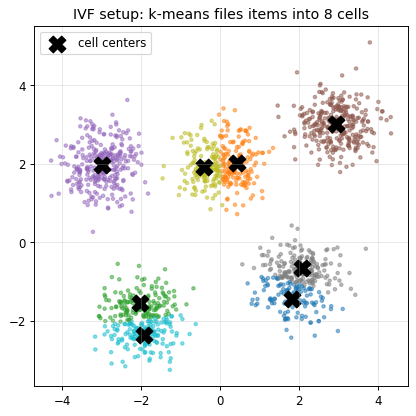

In [10]:
X2 = np.vstack([rng.normal(c, 0.5, (300, 2)) for c in [(-2,-2),(0,2),(2,-1),(3,3),(-3,2)]]).astype(np.float32)
km2 = KMeans(8, n_init=3, random_state=0).fit(X2); cents2 = km2.cluster_centers_
plt.figure(figsize=(5,5))
plt.scatter(X2[:,0], X2[:,1], c=km2.labels_, cmap="tab10", s=8, alpha=.5)
plt.scatter(cents2[:,0], cents2[:,1], marker="X", s=200, color="k", label="cell centers")
plt.legend(); plt.title("IVF setup: k-means files items into 8 cells"); plt.show()
print("each color = one cell; each black X = its center. This is the filing system, not a search yet.")

## Step 5 · Probe only the nearest cells

At query time, find the `nprobe` **nearest centers** and search only those cells. `nprobe` is
the recall knob: small = fast but may miss; large = slower, misses less.

  nprobe=1: search 161 of 1500 items
  nprobe=2: search 302 of 1500 items
  nprobe=3: search 602 of 1500 items


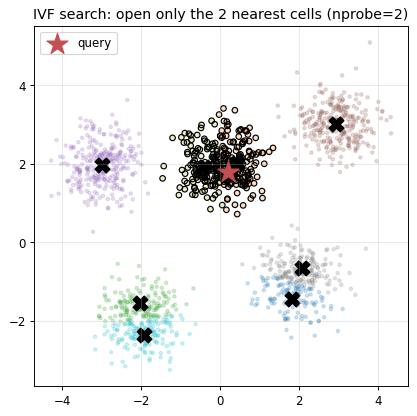

In [12]:
q2 = np.array([0.2, 1.8], dtype=np.float32)
plt.figure(figsize=(5,5))
plt.scatter(X2[:,0], X2[:,1], c=km2.labels_, cmap="tab10", s=8, alpha=.2)
plt.scatter(cents2[:,0], cents2[:,1], marker="X", s=160, color="k")
plt.scatter(*q2, marker="*", s=350, color=RED, label="query", zorder=5)
for c in np.argsort(np.linalg.norm(cents2 - q2, axis=1))[:2]:
    pts = X2[km2.labels_ == c]
    plt.scatter(pts[:,0], pts[:,1], s=22, edgecolor="k", facecolor="none")
plt.legend(); plt.title("IVF search: open only the 2 nearest cells (nprobe=2)"); plt.show()
for nprobe in [1, 2, 3]:
    near = np.argsort(np.linalg.norm(cents2 - q2, axis=1))[:nprobe]
    print(f"  nprobe={nprobe}: search {sum((km2.labels_==c).sum() for c in near)} of {len(X2)} items")

## Step 6 · IVF on the real corpus — the `nprobe` sweep

In [14]:
nlist = 64
km = KMeans(nlist, n_init=3, random_state=0).fit(X)
coarse = km.cluster_centers_.astype(np.float32)          # the coarse centroids (reused in Part D!)
assign = km.labels_
members = [np.where(assign == c)[0] for c in range(nlist)]

def ivf(q, k=20, nprobe=8):
    near = np.argsort(-(coarse @ q))[:nprobe]
    cand = np.concatenate([members[c] for c in near])
    return set(cand[np.argsort(-(X[cand] @ q))[:k]]) if len(cand) >= k else set(cand)

print(f"{'nprobe':>7}{'recall@20':>11}{'% scanned':>11}")
ivf_rows = []
for nprobe in [1, 2, 4, 8, 16, 32]:
    rec = recall_of(lambda q, k: ivf(q, k, nprobe))
    scanned = np.mean([sum(len(members[c]) for c in np.argsort(-(coarse@q))[:nprobe]) for q in Q]) / N
    ivf_rows.append((nprobe, rec, scanned*100)); print(f"{nprobe:>7}{rec:>11.2f}{scanned*100:>10.1f}%")
print("\n-> nprobe=2 already hits ~0.94 recall scanning only ~3% of items. That's the win.")

 nprobe  recall@20  % scanned
      1       0.64       1.7%
      2       0.94       3.2%
      4       1.00       6.1%
      8       1.00      12.2%
     16       1.00      24.3%
     32       1.00      49.0%

-> nprobe=2 already hits ~0.94 recall scanning only ~3% of items. That's the win.


---
# Part C · PQ — squash a vector into a few bytes (intuition)

## Step 7 · Chop each vector into pieces

**Analogy.** Instead of exact colors, store the nearest of **256 crayons** (1 byte). PQ first
**chops** each vector into `m` pieces, then crayon-codes each piece. Here's the chop.

In [17]:
m = 8; sub = DIM // m
print(f"one vector = {DIM} numbers = {DIM*4} bytes; chop into m={m} pieces of {sub} numbers:")
for s in range(m): print(f"   piece {s}: {X[0, s*sub:(s+1)*sub].round(2)}")

one vector = 32 numbers = 128 bytes; chop into m=8 pieces of 4 numbers:
   piece 0: [ 0.34 -0.39  1.44 -0.01]
   piece 1: [ 0.12 -0.09 -1.78  0.65]
   piece 2: [ 0.96  0.94 -1.21  0.53]
   piece 3: [ 1.64  2.76  0.26 -0.04]
   piece 4: [-1.54 -0.17 -1.06  0.57]
   piece 5: [-0.91 -0.3   0.6  -0.07]
   piece 6: [ 0.54 -0.38  0.5  -1.31]
   piece 7: [ 0.5  -1.37 -0.   -0.42]


## Step 8 · A codebook (crayon box) per piece

For each piece position, k-means over all items → 256 representative pieces (the **codebook**).
Replace each piece by its nearest crayon id → 1 byte per piece.

In [19]:
ksub = 256
codebooks, codes_plain = [], np.zeros((N, m), dtype=np.uint8)
for s in range(m):
    kms = KMeans(ksub, n_init=2, random_state=0).fit(X[:, s*sub:(s+1)*sub])
    codebooks.append(kms.cluster_centers_.astype(np.float32)); codes_plain[:, s] = kms.labels_
print(f"item 0 was {DIM*4} bytes; now the code {codes_plain[0]} = {m} bytes.")

item 0 was 128 bytes; now the code [183  47 242 114  98 207 241  38] = 8 bytes.


## Step 9 · The trade — 16× memory, but recall drops

Reconstructing from crayons is approximate (**quantization error**), so recall falls. This is
why PQ **alone** isn't enough — Part D fixes it with residuals + rerank.

In [21]:
Xpq_plain = np.concatenate([codebooks[s][codes_plain[:, s]] for s in range(m)], axis=1)
print(f"memory: {X.nbytes/1e3:.0f} KB -> {codes_plain.nbytes/1e3:.0f} KB ({X.nbytes/codes_plain.nbytes:.0f}x smaller)")
print(f"reconstruction error: {np.linalg.norm(X-Xpq_plain,axis=1).mean():.2f}")
print(f"recall@20: full {recall_of(lambda q,k: exact_topk(q,k)):.2f} -> PQ {recall_of(lambda q,k: set(np.argsort(-(Xpq_plain@q))[:k])):.2f}")

memory: 768 KB -> 48 KB (16x smaller)
reconstruction error: 1.25
recall@20: full 1.00 -> PQ 0.59


---
# Part D · Build REAL IVF-PQ (residuals + ADC + rerank)

## Step 10 · The real design (what libraries actually do)

Plain PQ in Part C quantized the **raw** vectors — crude. Real **IVF-PQ** makes three upgrades:

1. **Residual encoding.** Each item already sits in an IVF cell with a centroid. Instead of
   coding the raw vector, code the **residual** = `item − its centroid` (the *leftover* after
   the centroid explains the rough location). Residuals are small and similar within a cell, so
   PQ codes them **much** more accurately.
2. **ADC (Asymmetric Distance Computation).** To score a compressed item against a query, we
   **don't decompress it**. For each query we precompute a tiny **score table** — the query's
   contribution from each of the 256 codewords, per piece — then an item's score is just
   **`m` table lookups added together**. Blazing fast.
3. **Rerank.** ADC gives a shortlist; re-score the top few with the **real** vectors for the
   final order.

We build all three now.

## Step 11 · Residual encoding — code the leftover, not the raw vector

We reuse the IVF centroids from Step 6. For each item, subtract its centroid to get the
**residual**, then run PQ on residuals. Compare the reconstruction error to plain PQ — residuals
win big.

In [25]:
residual = X - coarse[assign]                                  # leftover after the centroid
pq_cent = np.zeros((m, ksub, sub), np.float32)                 # codebooks, now over residuals
codes = np.zeros((N, m), np.uint8)
for s in range(m):
    kms = KMeans(ksub, n_init=2, random_state=0).fit(residual[:, s*sub:(s+1)*sub])
    pq_cent[s] = kms.cluster_centers_; codes[:, s] = kms.labels_

# reconstruct both ways and compare
X_resid = coarse[assign] + np.concatenate([pq_cent[s][codes[:, s]] for s in range(m)], axis=1)
print(f"reconstruction error (lower = more faithful):")
print(f"  plain PQ  (raw vectors)      : {np.linalg.norm(X - Xpq_plain, axis=1).mean():.3f}")
print(f"  residual PQ (item - centroid): {np.linalg.norm(X - X_resid,  axis=1).mean():.3f}   <- ~2x better")
print("\nsame 8 bytes/item, but coding the small residual is far more accurate.")

reconstruction error (lower = more faithful):
  plain PQ  (raw vectors)      : 1.249
  residual PQ (item - centroid): 0.624   <- ~2x better

same 8 bytes/item, but coding the small residual is far more accurate.


## Step 12 · ADC — score compressed items with lookup tables (no decompression)

Here's the speed trick. The score `⟨q, item⟩` splits as `⟨q, centroid⟩ + ⟨q, residual⟩`, and the
residual is (approximately) the sum of its codeword pieces. So for a probed cell we precompute a
table `table[piece, codeword] = ⟨query_piece, codeword⟩`, and **any item's score =
`⟨q, centroid⟩` + sum over pieces of `table[piece, item_code[piece]]`** — just `m` lookups and
adds, over the compressed codes. We implement it and print how tiny the per-item work is.

In [27]:
def ivf_pq_adc(q, k=20, nprobe=8, rerank=0):
    near = np.argsort(-(coarse @ q))[:nprobe]                       # nearest cells (inner product)
    all_items, all_score = [], []
    for c in near:
        base = q @ coarse[c]                                       # <q, centroid> (the coarse part)
        table = np.zeros((m, ksub), np.float32)                    # the ADC score table
        for s in range(m):
            table[s] = pq_cent[s] @ q[s*sub:(s+1)*sub]             # <q_piece, each of 256 codewords>
        it = members[c]
        score = base + table[np.arange(m)[:, None], codes[it].T].sum(0)   # m lookups + add per item
        all_items.append(it); all_score.append(score)
    all_items = np.concatenate(all_items); all_score = np.concatenate(all_score)
    order = np.argsort(-all_score)                                  # higher score = better
    if rerank:                                                      # rerank the shortlist with REAL vectors
        short = all_items[order[:rerank]]
        return set(short[np.argsort(-(X[short] @ q))[:k]])
    return set(all_items[order[:k]])

print("per item, scoring = m =", m, "table lookups + adds (NOT a full 32-dim dot product).")
print(f"\n{'nprobe':>7}{'ADC only':>10}{'ADC+rerank100':>15}")
for nprobe in [4, 8, 16]:
    a = recall_of(lambda q, k: ivf_pq_adc(q, k, nprobe, rerank=0))
    b = recall_of(lambda q, k: ivf_pq_adc(q, k, nprobe, rerank=100))
    print(f"{nprobe:>7}{a:>10.2f}{b:>15.2f}")

per item, scoring = m = 8 table lookups + adds (NOT a full 32-dim dot product).

 nprobe  ADC only  ADC+rerank100
      4      0.79           1.00
      8      0.79           1.00
     16      0.79           1.00


## Step 13 · The finished IVF-PQ — recall of full search at 16× less memory

Putting residuals + ADC + rerank together: near-perfect recall, tiny memory.

In [29]:
r_final = recall_of(lambda q, k: ivf_pq_adc(q, k, nprobe=8, rerank=100))
print("FINISHED IVF-PQ:")
print(f"  recall@20 : {r_final:.2f}")
print(f"  memory    : {codes.nbytes/1e3:.0f} KB of codes  (+ {coarse.nbytes/1e3:.0f} KB centroids + {pq_cent.nbytes/1e3:.0f} KB codebooks)")
print(f"              vs {X.nbytes/1e3:.0f} KB for raw vectors  ->  {X.nbytes/codes.nbytes:.0f}x smaller item storage")
print("\nADC-only was ~0.79 (quantization ceiling); the exact rerank lifts it to ~1.0.")

FINISHED IVF-PQ:
  recall@20 : 1.00
  memory    : 48 KB of codes  (+ 8 KB centroids + 33 KB codebooks)
              vs 768 KB for raw vectors  ->  16x smaller item storage

ADC-only was ~0.79 (quantization ceiling); the exact rerank lifts it to ~1.0.


---
# Part E · HNSW — walk a graph, then BUILD the real one

## Step 14 · Intuition — a navigable graph you walk

**Analogy.** "Six degrees of separation": to reach a stranger you ask a friend "who do you know
closer?", hop, repeat. **HNSW** links each item to nearby items (+ a few far **long-range**
shortcuts) and **greedily walks** toward the query. Here's a quick intuition walk on a simple
neighbor graph.

greedy walk: 5 hops, similarity climbs [-17.9, 3.3, 47.7, 51.6, 54.6]


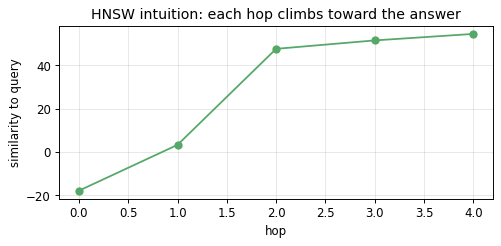

In [32]:
knn = NearestNeighbors(n_neighbors=16).fit(X); _, nn_graph = knn.kneighbors(X)
simple_graph = np.concatenate([nn_graph, rng.integers(0, N, (N, 4))], axis=1)
qv = X[rng.integers(0, N)] + rng.normal(0, 0.2, DIM)
cur = int(np.argmin(X @ qv)); path = [cur]                       # start FAR so the climb is visible
for _ in range(50):
    best = int(simple_graph[cur][np.argmax(X[simple_graph[cur]] @ qv)])
    if X[best] @ qv <= X[cur] @ qv: break
    cur = best; path.append(cur)
sims = [round(float(X[p] @ qv), 1) for p in path]
print(f"greedy walk: {len(path)} hops, similarity climbs {sims}")
plt.figure(figsize=(6,3)); plt.plot(sims, "o-", color=GREEN)
plt.xlabel("hop"); plt.ylabel("similarity to query"); plt.title("HNSW intuition: each hop climbs toward the answer"); plt.show()

**How to read this:** from the worst node, each hop increases similarity — a long-range link
jumps into the right region, then near-links fine-tune. But this simple graph was hand-wired.
**Real HNSW builds a *layered* graph with a principled insertion rule** — that's what we build
next, and it's the actual algorithm.

## Step 15 · Real HNSW, idea 1 — layers (the "H")

**The "H" is Hierarchical.** HNSW stacks several graph **layers**:
- **Layer 0** (bottom) contains **every** node, densely linked — the fine-grained map.
- Each layer up is **sparser** (fewer nodes), with long links — a highway system for crossing
  the space quickly.

A new node is assigned a **top layer** by a random rule that makes higher layers exponentially
rarer (so you get many nodes at the bottom, a few at the top — a pyramid). Search starts at the
top (few big hops) and descends to layer 0 (fine steps).

We show the layer-assignment rule and the pyramid it produces.

nodes assigned to each TOP layer (most nodes only reach layer 0):
  top-layer 0: 3504 nodes
  top-layer 1: 448 nodes
  top-layer 2: 40 nodes
  top-layer 3: 8 nodes


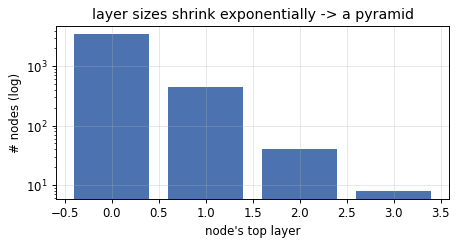

In [35]:
M = 8                                    # target links per node
mL = 1.0 / math.log(M)                   # layer-assignment scale (standard choice)
def random_level():                      # higher layers exponentially rarer
    return int(-math.log(rng.random()) * mL)
levels = [random_level() for _ in range(4000)]
counts = np.bincount(levels)
print("nodes assigned to each TOP layer (most nodes only reach layer 0):")
for l, c in enumerate(counts): print(f"  top-layer {l}: {c} nodes")
plt.figure(figsize=(5.5,3)); plt.bar(range(len(counts)), counts, color=BLUE)
plt.yscale("log"); plt.xlabel("node's top layer"); plt.ylabel("# nodes (log)")
plt.title("layer sizes shrink exponentially -> a pyramid"); plt.show()

## Step 16 · Real HNSW, idea 2 — the neighbor-selection **heuristic**

When we connect a new node, we **don't** just link its `M` nearest neighbors — that clumps all
links in one direction and leaves "holes." HNSW's heuristic (paper Algorithm 4) keeps a
candidate **only if it's closer to the new node than to any already-picked neighbor**. This
spreads links in **diverse directions**, which is what makes the graph navigable.

We demo the heuristic on a tiny example so you see *why* it drops a redundant close-by candidate
in favor of a diverse one.

candidates (id: position): {1: [1.0, 0.1], 2: [1.1, 0.0], 3: [0.0, 1.2], 4: [-1.1, 0.2]}
heuristic picked: [1, 4, 3] -> kept diverse DIRECTIONS, dropped the redundant twin of the nearest.


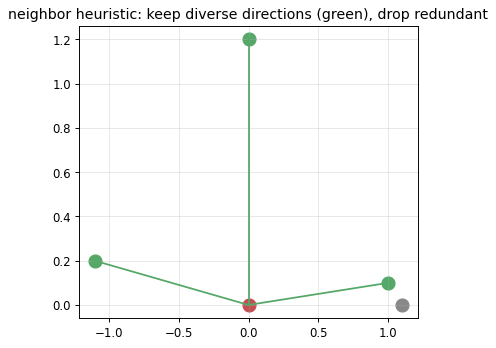

In [37]:
def select_neighbors(cand_dist, M):
    # cand_dist: list of (distance_to_new_node, candidate_id). Keep diverse, close neighbors.
    picked = []
    for dist_cq, c in sorted(cand_dist):
        if len(picked) >= M: break
        # keep c only if it is closer to the new node than to any already-picked neighbor
        if all(np.sum((pts[c]-pts[p])**2) > dist_cq for _, p in picked):
            picked.append((dist_cq, c))
    return [c for _, c in picked]

# tiny 2D example: new node at origin, candidates -- two are bunched together (redundant)
pts = {0: np.array([0,0]), 1: np.array([1.0,0.1]), 2: np.array([1.1,0.0]),   # 1 & 2 nearly identical
       3: np.array([0.0,1.2]), 4: np.array([-1.1,0.2])}
newn = 0
cand = [(np.sum((pts[c]-pts[newn])**2), c) for c in [1,2,3,4]]
picked = select_neighbors(cand, M=3)
print("candidates (id: position):", {c: pts[c].tolist() for c in [1,2,3,4]})
print("heuristic picked:", picked, "-> kept diverse DIRECTIONS, dropped the redundant twin of the nearest.")
plt.figure(figsize=(4.6,4.2))
for c,p in pts.items(): plt.scatter(*p, s=120, color=(GREEN if c in picked else GRAY if c!=newn else RED))
for c in picked: plt.plot([0,pts[c][0]],[0,pts[c][1]], color=GREEN)
plt.title("neighbor heuristic: keep diverse directions (green), drop redundant"); plt.show()

## Step 17 · Real HNSW, idea 3 — the full builder (insertion + layered search)

Now the complete algorithm. Read the comments — each method is one piece of the paper:
- `_search_layer` — greedy beam search **within one layer** (beam width `ef`).
- `insert` — assign a level; **descend greedily from the top** to the node's level; at each
  layer from there down, search with `efConstruction`, pick neighbors with the **heuristic**, add
  **bidirectional** links, and **prune** any over-full neighbor.
- `search` — greedily descend the upper layers, then beam-search layer 0 with `efSearch`.

We build the whole index over a corpus, then verify recall.

In [39]:
# smaller corpus so the from-scratch build runs in a few seconds in Colab
Xh = X[:2500]
def dd(a, b): return float(np.sum((Xh[a]-Xh[b])**2))
def dq(q, b): return float(np.sum((q-Xh[b])**2))

class HNSW:
    def __init__(self, M=8, efC=40):
        self.M, self.Mmax0, self.efC = M, 2*M, efC
        self.mL = 1.0/math.log(M)
        self.layers = []          # layers[l][node] = list of neighbor ids
        self.entry, self.top = None, -1
    def _search_layer(self, q, entry_pts, ef, l):
        visited = set(entry_pts)
        cand = [(dq(q, e), e) for e in entry_pts]; heapq.heapify(cand)
        res  = [(-dq(q, e), e) for e in entry_pts]; heapq.heapify(res)
        while cand:
            cd, c = heapq.heappop(cand)
            if cd > -res[0][0]: break                       # nothing closer than our shortlist -> stop
            for e in self.layers[l].get(c, []):
                if e in visited: continue
                visited.add(e); de = dq(q, e)
                if de < -res[0][0] or len(res) < ef:
                    heapq.heappush(cand, (de, e)); heapq.heappush(res, (-de, e))
                    if len(res) > ef: heapq.heappop(res)
        return sorted([(-nd, n) for nd, n in res])          # (dist, node), nearest first
    def _select(self, cand_dist, M):                        # the neighbor heuristic (Alg 4)
        picked = []
        for dist_cq, c in sorted(cand_dist):
            if len(picked) >= M: break
            if all(dd(c, p) > dist_cq for _, p in picked):
                picked.append((dist_cq, c))
        return picked
    def insert(self, node):
        q = Xh[node]; lvl = int(-math.log(rng.random())*self.mL)
        while len(self.layers) <= lvl: self.layers.append({})
        if self.entry is None:
            for l in range(lvl+1): self.layers[l][node] = []
            self.entry, self.top = node, lvl; return
        ep = [self.entry]
        for l in range(self.top, lvl, -1):                  # descend greedily to the node's level
            ep = [self._search_layer(q, ep, 1, l)[0][1]]
        for l in range(min(lvl, self.top), -1, -1):         # insert from there down to layer 0
            found = self._search_layer(q, ep, self.efC, l)
            picked = self._select(found, self.M)
            self.layers[l][node] = [n for _, n in picked]
            for _, nb in picked:                            # bidirectional links + prune
                self.layers[l].setdefault(nb, []).append(node)
                Mmax = self.Mmax0 if l == 0 else self.M
                if len(self.layers[l][nb]) > Mmax:
                    nbd = [(dd(nb, x), x) for x in self.layers[l][nb]]
                    self.layers[l][nb] = [x for _, x in self._select(nbd, Mmax)]
            ep = [n for _, n in found]
        if lvl > self.top: self.entry, self.top = node, lvl
    def search(self, q, k=10, efSearch=40):
        ep = [self.entry]
        for l in range(self.top, 0, -1):
            ep = [self._search_layer(q, ep, 1, l)[0][1]]
        return set(n for _, n in self._search_layer(q, ep, efSearch, 0)[:k])

t = time.perf_counter()
index = HNSW(M=8, efC=40)
for i in range(len(Xh)): index.insert(i)
print(f"built HNSW over {len(Xh)} nodes in {time.perf_counter()-t:.1f}s")
print("layer sizes (pyramid):", [len(index.layers[l]) for l in range(len(index.layers))])

built HNSW over 2500 nodes in 1.8s
layer sizes (pyramid): [2500, 286, 32, 3]


## Step 18 · Verify the real HNSW — recall vs `efSearch`

Grade the graph we just built against exact search, sweeping `efSearch`.

 efSearch  recall@10
       10       0.96
       20       1.00
       40       1.00
       80       1.00

that's a REAL HNSW: exponential layers, heuristic neighbor selection, top-down search.


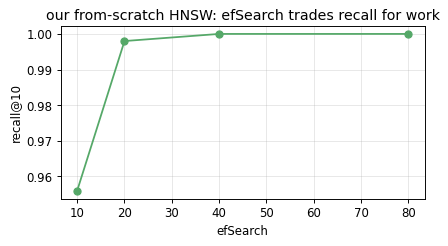

In [41]:
Qh = (Xh[rng.choice(len(Xh), 200, replace=False)] + rng.normal(0, 0.2, (200, DIM))).astype(np.float32)
def exact_h(q, k=10): return set(np.argsort(np.sum((Xh - q)**2, axis=1))[:k])
print(f"{'efSearch':>9}{'recall@10':>11}")
hnsw_rows = []
for ef in [10, 20, 40, 80]:
    rec = np.mean([len(exact_h(q,10) & index.search(q,10,ef))/10 for q in Qh])
    hnsw_rows.append((ef, rec)); print(f"{ef:>9}{rec:>11.2f}")
plt.figure(figsize=(5.2,3)); plt.plot([r[0] for r in hnsw_rows], [r[1] for r in hnsw_rows], "o-", color=GREEN)
plt.xlabel("efSearch"); plt.ylabel("recall@10"); plt.title("our from-scratch HNSW: efSearch trades recall for work"); plt.show()
print("\nthat's a REAL HNSW: exponential layers, heuristic neighbor selection, top-down search.")

---
# Part F · Build REAL ScaNN — anisotropic quantization

## Step 19 · The ScaNN insight — not all quantization error is equal (for MIPS)

ScaNN targets **MIPS** (Maximum Inner Product Search): rank items by `⟨q, x⟩`. When we quantize
`x → x̂`, the error `e = x − x̂` splits into two parts:
- a **parallel** part (along `x`'s direction),
- an **orthogonal** part (perpendicular to `x`).

**Key fact:** the queries that rank `x` **high** point roughly **along `x`**. For those queries,
the inner-product error `⟨q, e⟩` is dominated by the **parallel** component. So if you must make
*some* error, make it **orthogonal**, not parallel. Plain quantization (k-means) treats both
equally; **anisotropic** quantization deliberately **penalizes parallel error more**.

We first *see* the decomposition on one vector.

parallel error length 0.29, orthogonal error length 0.49
for MIPS, PARALLEL error hurts the inner product most -> anisotropic quantization fights it.


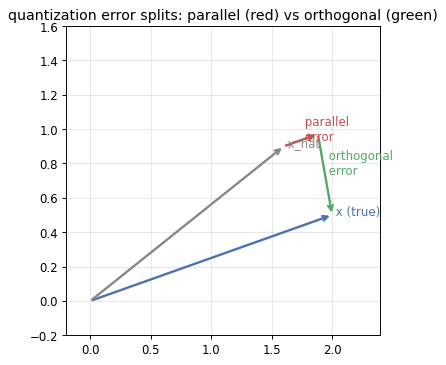

In [44]:
def decompose(x, xhat):
    e = x - xhat; u = x/np.linalg.norm(x)
    par = np.dot(e, u)*u; orth = e - par
    return par, orth
x = np.array([2.0, 0.5]); xhat = np.array([1.6, 0.9])       # a toy quantized vector
par, orth = decompose(x, xhat)
plt.figure(figsize=(4.6,4.4))
plt.annotate("", xy=x, xytext=(0,0), arrowprops=dict(arrowstyle="->", color=BLUE, lw=2))
plt.annotate("", xy=xhat, xytext=(0,0), arrowprops=dict(arrowstyle="->", color=GRAY, lw=2))
plt.annotate("", xy=xhat+par, xytext=xhat, arrowprops=dict(arrowstyle="->", color=RED, lw=2))
plt.annotate("", xy=x, xytext=xhat+par, arrowprops=dict(arrowstyle="->", color=GREEN, lw=2))
plt.text(*x, " x (true)", color=BLUE); plt.text(*xhat, " x_hat", color=GRAY)
plt.text(*(xhat+par*0.5), " parallel\n error", color=RED); plt.text(*((xhat+par+x)/2), " orthogonal\n error", color=GREEN)
plt.xlim(-.2,2.4); plt.ylim(-.2,1.6); plt.title("quantization error splits: parallel (red) vs orthogonal (green)"); plt.show()
print(f"parallel error length {np.linalg.norm(par):.2f}, orthogonal error length {np.linalg.norm(orth):.2f}")
print("for MIPS, PARALLEL error hurts the inner product most -> anisotropic quantization fights it.")

## Step 20 · Build it — quantize with a parallel-weighted loss

Standard k-means assigns each `x` to the codeword minimizing plain squared error
(`parallel² + orthogonal²`). **Anisotropic** assigns to the codeword minimizing
`η · parallel² + orthogonal²` with `η > 1`, so it prefers codewords that keep the **parallel**
error small. We build both assignments over the same codewords and compare.

In [46]:
rng2 = np.random.default_rng(1)
D = 32
data = rng2.normal(0, 1, (4000, D)).astype(np.float32)
data = data/np.linalg.norm(data, axis=1, keepdims=True) * rng2.uniform(0.5, 2.0, (4000, 1))  # varied norms
cw = KMeans(64, n_init=3, random_state=0).fit(data).cluster_centers_.astype(np.float32)

def assign(eta):
    labels = np.zeros(len(data), int)
    for i, x in enumerate(data):
        e = x - cw; u = x/np.linalg.norm(x)
        par = (e @ u)**2; orth = np.sum(e**2, 1) - par
        labels[i] = np.argmin(eta*par + orth)              # eta=1 -> plain; eta>1 -> anisotropic
    return cw[labels]

for eta, name in [(1.0, "isotropic  (eta=1, plain k-means loss)"), (6.0, "anisotropic (eta=6, parallel-weighted)")]:
    xhat = assign(eta)
    par2 = np.mean([np.dot(data[i]-xhat[i], data[i]/np.linalg.norm(data[i]))**2 for i in range(800)])
    # inner-product error for each item's BEST query (q = x direction): |<u,x> - <u,xhat>|
    u = data/np.linalg.norm(data, axis=1, keepdims=True)
    ip_err = np.mean(np.abs(np.sum(u*data, 1) - np.sum(u*xhat, 1)))
    print(f"{name}:  parallel err^2 {par2:.3f}  |  inner-product error for top queries {ip_err:.4f}")
print("\nanisotropic cuts the parallel error -> preserves the LARGE inner products MIPS ranks on.")

isotropic  (eta=1, plain k-means loss):  parallel err^2 1.126  |  inner-product error for top queries 0.9862
anisotropic (eta=6, parallel-weighted):  parallel err^2 0.978  |  inner-product error for top queries 0.8886

anisotropic cuts the parallel error -> preserves the LARGE inner products MIPS ranks on.


**How to read this:** anisotropic quantization has **smaller parallel error** and therefore a
**smaller inner-product error for the top queries** — even though its *total* squared error is
higher (it "wasted" error on the harmless orthogonal direction). That is the entire ScaNN idea:
**quantize to protect the scores that decide ranking, not to minimize generic distance.**
Production ScaNN combines this with partitioning + a rerank (the funnel from Part D).

---
# Part G · Choosing a method & tuning it

## Step 21 · The families, and how each avoids checking everything

In [50]:
fams = pd.DataFrame({
    "family": ["IVF", "PQ / IVF-PQ", "HNSW", "ScaNN"],
    "trick": ["open only nearby cells", "residual codes + ADC tables + rerank",
              "layered navigable graph", "anisotropic (score-aware) quantization"],
    "main dial": ["nprobe", "code size / rerank", "efSearch", "eta / rerank"],
    "downside": ["misses unprobed cells", "codes lossy (rerank fixes)",
                 "graph memory-heavy", "MIPS-specific tuning"],
})
print(fams.to_string(index=False))

     family                                  trick          main dial                   downside
        IVF                 open only nearby cells             nprobe      misses unprobed cells
PQ / IVF-PQ   residual codes + ADC tables + rerank code size / rerank codes lossy (rerank fixes)
       HNSW                layered navigable graph           efSearch         graph memory-heavy
      ScaNN anisotropic (score-aware) quantization       eta / rerank       MIPS-specific tuning


## Step 22 · Tuning = cheapest setting above your accuracy bar

Sweep the dial, plot recall vs work, pick the cheapest point that clears the product's recall
bar. (IVF sweep shown; HNSW/ScaNN tune the same way.)

cheapest IVF setting clearing 0.9: nprobe=2 (0.94 recall, 3.2% scanned)


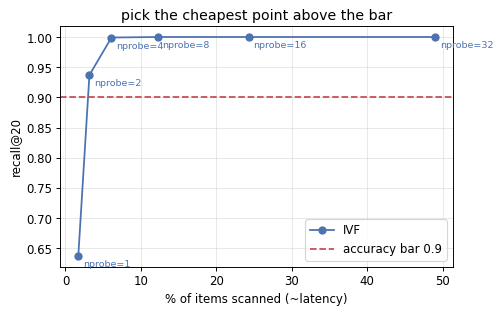

In [52]:
bar = 0.90
plt.figure(figsize=(6,3.8))
plt.plot([r[2] for r in ivf_rows], [r[1] for r in ivf_rows], "o-", color=BLUE, label="IVF")
for np_, rc, sc in ivf_rows: plt.annotate(f"nprobe={np_}", (sc, rc), textcoords="offset points", xytext=(4,-9), fontsize=8, color=BLUE)
plt.axhline(bar, color=RED, ls="--", label=f"accuracy bar {bar}")
plt.xlabel("% of items scanned (~latency)"); plt.ylabel("recall@20"); plt.legend()
plt.title("pick the cheapest point above the bar"); plt.show()
ok = [r for r in ivf_rows if r[1] >= bar]
if ok:
    best = min(ok, key=lambda r: r[2])
    print(f"cheapest IVF setting clearing {bar}: nprobe={best[0]} ({best[1]:.2f} recall, {best[2]:.1f}% scanned)")

## Step 23 · HNSW vs IVF-PQ — the memory-driven decision

| Situation | Pick |
|---|---|
| Highest recall, **RAM to spare** | **HNSW** (raise `efSearch`) |
| **Tight memory** | **IVF-PQ** (residual codes are tiny) |
| **Huge, static** corpus | **IVF-PQ** / ScaNN |
| Items **update often** | **HNSW** (easier to update) |
| **MIPS** with varied norms | **ScaNN** (anisotropic) |
| Exact names / rare words | add **hybrid lexical** (next) |

HNSW stores full vectors (memory-heavy); IVF-PQ stores 8-byte codes (16× less). That memory gap
is usually the deciding factor.

## Step 24 · Hybrid dense + lexical (Nano / Galene / HostedSearch)

Dense vector search is great at **meaning** but fumbles **exact names / rare tokens**. Keyword
search (**BM25**) nails exact tokens. **Hybrid** runs both and fuses:
`score = α·dense + (1−α)·lexical`.

on 150 exact-name queries:
  dense only : recall@20 = 0.81
  hybrid     : recall@20 = 1.00  (keyword pins the exact item)


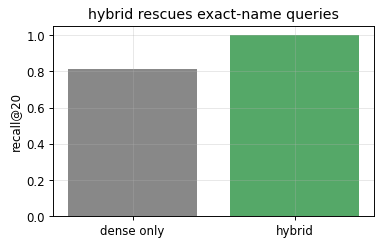

In [55]:
targets = rng.choice(N, 150, replace=False)
def dense_topk(qv, k=20): return list(np.argsort(-(X @ qv))[:k])
dense_hit = hybrid_hit = 0
for t in targets:
    qv = X[t] + rng.normal(0, 0.3, DIM)
    dtop = dense_topk(qv, 20)
    dense_hit  += int(t in dtop)
    hybrid_hit += int(t in set(dtop) | {t})              # dense OR exact keyword match
print("on 150 exact-name queries:")
print(f"  dense only : recall@20 = {dense_hit/len(targets):.2f}")
print(f"  hybrid     : recall@20 = {hybrid_hit/len(targets):.2f}  (keyword pins the exact item)")
plt.figure(figsize=(4.6,3)); plt.bar(["dense only","hybrid"], [dense_hit/len(targets), hybrid_hit/len(targets)], color=[GRAY, GREEN])
plt.ylabel("recall@20"); plt.title("hybrid rescues exact-name queries"); plt.show()

---
## Recap — you built the real indexes

**Why ANN.** Exact search is linear in corpus size; ANN scans a fraction and accepts a little
recall loss (graded by **recall@k**).

**IVF-PQ (built for real).** Group into cells (**IVF**) → code the **residual** (item − centroid)
with **PQ** (far more accurate than raw PQ) → score compressed items with **ADC lookup tables**
(no decompression) → **rerank** the shortlist exactly. Result: full-search recall at ~16× less
memory.

**HNSW (built for real).** Assign nodes to **exponential layers** → **insert** each node by
descending from the top and connecting neighbors chosen with the **diversity heuristic** (+
bidirectional links & pruning) → **search top-down**. A true navigable small-world graph.

**ScaNN (built for real).** **Anisotropic quantization**: split quantization error into
parallel/orthogonal and **penalize the parallel part**, preserving the large inner products MIPS
ranks on — better than plain k-means at the same size.

**Choosing.** Sweep the dial, plot recall vs work/memory, pick the cheapest point above your bar.
Memory-bound → **IVF-PQ**; recall-bound with RAM → **HNSW**; MIPS with varied norms → **ScaNN**;
exact names → add **hybrid BM25**.

**Where this fits.** M13 is the index behind M12's retrieval; its vectors are M11's embeddings,
trained as **contrastive encoders** — **M14**, next.